## Loading Libraries

In [14]:
import os
import zipfile
import requests
import numpy as np
import pandas as pd
import plotly.express as px
import folium

from tqdm import tqdm
from pathlib import Path

## Creating Dummy Data

In [15]:
trip_demo = pd.DataFrame({
    "ride_id": list(range(1, 21)),

    "start_station": [
        "Station A", "Station A", "Station A", "Station A", "Station A",
        "Station B", "Station B", "Station B", "Station B",
        "Station C", "Station C", "Station C",
        "Station D", "Station D", "Station D",
        "Station E", "Station E",
        "Station A", "Station B", "Station C"
    ],

    "end_station": [
        "Station B", "Station B", "Station B", "Station C", "Station C",
        "Station A", "Station A", "Station C", "Station D",
        "Station A", "Station B", "Station E",
        "Station A", "Station C", "Station E",
        "Station A", "Station D",
        "Station E", "Station E", "Station D"
    ],

    "started_at": pd.to_datetime([
        "2025-01-01 08:00", "2025-01-01 08:15", "2025-01-01 08:30",
        "2025-01-01 09:00", "2025-01-01 09:20",
        "2025-01-01 10:00", "2025-01-01 10:15", "2025-01-01 10:40",
        "2025-01-01 11:00",
        "2025-01-01 11:30", "2025-01-01 12:00", "2025-01-01 12:20",
        "2025-01-01 13:00", "2025-01-01 13:30", "2025-01-01 14:00",
        "2025-01-01 14:30", "2025-01-01 15:00",
        "2025-01-01 15:30", "2025-01-01 16:00", "2025-01-01 16:30"
    ]),

    "ended_at": pd.to_datetime([
        "2025-01-01 08:10", "2025-01-01 08:28", "2025-01-01 08:42",
        "2025-01-01 09:18", "2025-01-01 09:35",
        "2025-01-01 10:12", "2025-01-01 10:30", "2025-01-01 10:55",
        "2025-01-01 11:18",
        "2025-01-01 11:48", "2025-01-01 12:14", "2025-01-01 12:45",
        "2025-01-01 13:20", "2025-01-01 13:48", "2025-01-01 14:20",
        "2025-01-01 14:55", "2025-01-01 15:22",
        "2025-01-01 15:58", "2025-01-01 16:25", "2025-01-01 16:50"
    ]),

    "member_casual": [
        "member", "member", "casual", "member", "casual",
        "member", "member", "casual", "member",
        "casual", "member", "casual",
        "member", "casual", "member",
        "casual", "member",
        "member", "casual", "member"
    ]
})

trip_demo

,ride_id,start_station,end_station,started_at,ended_at,member_casual
0,1,Station A,Station B,2025-01-01 08:00:00,2025-01-01 08:10:00,member
1,2,Station A,Station B,2025-01-01 08:15:00,2025-01-01 08:28:00,member
2,3,Station A,Station B,2025-01-01 08:30:00,2025-01-01 08:42:00,casual
3,4,Station A,Station C,2025-01-01 09:00:00,2025-01-01 09:18:00,member
4,5,Station A,Station C,2025-01-01 09:20:00,2025-01-01 09:35:00,casual
5,6,Station B,Station A,2025-01-01 10:00:00,2025-01-01 10:12:00,member
6,7,Station B,Station A,2025-01-01 10:15:00,2025-01-01 10:30:00,member
7,8,Station B,Station C,2025-01-01 10:40:00,2025-01-01 10:55:00,casual
8,9,Station B,Station D,2025-01-01 11:00:00,2025-01-01 11:18:00,member
9,10,Station C,Station A,2025-01-01 11:30:00,2025-01-01 11:48:00,casual


In [16]:
station_coordinates = pd.DataFrame({
    "station": [
        "Station A",
        "Station B",
        "Station C",
        "Station D",
        "Station E"
    ],
    "lat": [
        40.735,
        40.751,
        40.742,
        40.728,
        40.760
    ],
    "lng": [
        -73.991,
        -73.977,
        -73.985,
        -73.970,
        -73.995
    ]
})

station_coordinates

,station,lat,lng
0,Station A,40.735,-73.991
1,Station B,40.751,-73.977
2,Station C,40.742,-73.985
3,Station D,40.728,-73.970
4,Station E,40.760,-73.995


In [17]:
start_df = trip_demo.merge(station_coordinates,how='left',left_on='start_station',right_on='station')
start_df.rename(columns={
    'lat':'start_lat',
    'lng': 'start_lng'    
}, inplace = True)



In [18]:
end_df = trip_demo.merge(station_coordinates,how='left',left_on='end_station',right_on='station')

end_df.rename(columns={
    'lat':'end_lat',
    'lng': 'end_lng'    
}, inplace = True)

end_df.drop(columns=['station'], inplace=True)
end_df.head()

,ride_id,start_station,end_station,started_at,ended_at,member_casual,end_lat,end_lng
0,1,Station A,Station B,2025-01-01 08:00:00,2025-01-01 08:10:00,member,40.751,-73.977
1,2,Station A,Station B,2025-01-01 08:15:00,2025-01-01 08:28:00,member,40.751,-73.977
2,3,Station A,Station B,2025-01-01 08:30:00,2025-01-01 08:42:00,casual,40.751,-73.977
3,4,Station A,Station C,2025-01-01 09:00:00,2025-01-01 09:18:00,member,40.742,-73.985
4,5,Station A,Station C,2025-01-01 09:20:00,2025-01-01 09:35:00,casual,40.742,-73.985


In [19]:

start_cols = ['ride_id', 'start_station','started_at','start_lat', 'start_lng']
end_cols = ['ride_id', 'end_station','ended_at','end_lat', 'end_lng', 'member_casual']

In [20]:
trip_demo = pd.merge(start_df[start_cols], end_df[end_cols],how='inner', on= 'ride_id')
trip_demo.head()

,ride_id,start_station,started_at,start_lat,start_lng,end_station,ended_at,end_lat,end_lng,member_casual
0,1,Station A,2025-01-01 08:00:00,40.735,-73.991,Station B,2025-01-01 08:10:00,40.751,-73.977,member
1,2,Station A,2025-01-01 08:15:00,40.735,-73.991,Station B,2025-01-01 08:28:00,40.751,-73.977,member
2,3,Station A,2025-01-01 08:30:00,40.735,-73.991,Station B,2025-01-01 08:42:00,40.751,-73.977,casual
3,4,Station A,2025-01-01 09:00:00,40.735,-73.991,Station C,2025-01-01 09:18:00,40.742,-73.985,member
4,5,Station A,2025-01-01 09:20:00,40.735,-73.991,Station C,2025-01-01 09:35:00,40.742,-73.985,casual


In [21]:
map_center = [
    pd.concat([trip_demo["start_lat"], trip_demo["end_lat"]]).mean(),
    pd.concat([trip_demo["start_lng"], trip_demo["end_lng"]]).mean()
]

map_center

[np.float64(40.7427), np.float64(-73.9841)]

In [22]:
trip_demo["duration_min"] = (
    trip_demo["ended_at"] - trip_demo["started_at"]
).dt.total_seconds() / 60

trip_demo.head()

,ride_id,start_station,started_at,start_lat,start_lng,end_station,ended_at,end_lat,end_lng,member_casual,duration_min
0,1,Station A,2025-01-01 08:00:00,40.735,-73.991,Station B,2025-01-01 08:10:00,40.751,-73.977,member,10.0
1,2,Station A,2025-01-01 08:15:00,40.735,-73.991,Station B,2025-01-01 08:28:00,40.751,-73.977,member,13.0
2,3,Station A,2025-01-01 08:30:00,40.735,-73.991,Station B,2025-01-01 08:42:00,40.751,-73.977,casual,12.0
3,4,Station A,2025-01-01 09:00:00,40.735,-73.991,Station C,2025-01-01 09:18:00,40.742,-73.985,member,18.0
4,5,Station A,2025-01-01 09:20:00,40.735,-73.991,Station C,2025-01-01 09:35:00,40.742,-73.985,casual,15.0


In [23]:
trip_demo["date"] = trip_demo["started_at"].dt.date
trip_demo["hour"] = trip_demo["started_at"].dt.hour
trip_demo["day_name"] = trip_demo["started_at"].dt.day_name()
trip_demo["month_name"] = trip_demo["started_at"].dt.month_name()

trip_demo.head()

,ride_id,start_station,started_at,start_lat,start_lng,end_station,ended_at,end_lat,end_lng,member_casual,duration_min,date,hour,day_name,month_name
0,1,Station A,2025-01-01 08:00:00,40.735,-73.991,Station B,2025-01-01 08:10:00,40.751,-73.977,member,10.0,2025-01-01,8,Wednesday,January
1,2,Station A,2025-01-01 08:15:00,40.735,-73.991,Station B,2025-01-01 08:28:00,40.751,-73.977,member,13.0,2025-01-01,8,Wednesday,January
2,3,Station A,2025-01-01 08:30:00,40.735,-73.991,Station B,2025-01-01 08:42:00,40.751,-73.977,casual,12.0,2025-01-01,8,Wednesday,January
3,4,Station A,2025-01-01 09:00:00,40.735,-73.991,Station C,2025-01-01 09:18:00,40.742,-73.985,member,18.0,2025-01-01,9,Wednesday,January
4,5,Station A,2025-01-01 09:20:00,40.735,-73.991,Station C,2025-01-01 09:35:00,40.742,-73.985,casual,15.0,2025-01-01,9,Wednesday,January


## Folium

In [24]:
map_center

[np.float64(40.7427), np.float64(-73.9841)]

In [29]:
m = folium.Map(
    location=map_center,
    zoom_start=13
)
m

In [39]:
for _, row in station_coordinates.iterrows():
    folium.Marker(
        location=[row["lat"], row["lng"]],
        popup=row["station"],
        tooltip = row['station']
    ).add_to(m)

m

In [46]:
# m = folium.Map(
#     location=map_center,
#     zoom_start=13
# )

start_point = [trip_demo.loc[0, "start_lat"], trip_demo.loc[0, "start_lng"]]
end_point = [trip_demo.loc[0, "end_lat"], trip_demo.loc[0, "end_lng"]]

folium.Marker(start_point, popup="Start").add_to(m)
folium.Marker(end_point, popup="End").add_to(m)

folium.PolyLine(
    locations=[start_point, end_point],
    weight=5,
    opacity=0.8
).add_to(m)

m

In [ ]:
import geopandas as gpd
start_points = gpd.GeoDataFrame(
    trip_demo.copy(),
    geometry=gpd.points_from_xy(
        trip_demo["start_lng"],
        trip_demo["start_lat"]
    ),
    crs="EPSG:4326"
)

end_points = gpd.GeoDataFrame(
    trip_demo.copy(),
    geometry=gpd.points_from_xy(
        trip_demo["end_lng"],
        trip_demo["end_lat"]
    ),
    crs="EPSG:4326"
)

In [48]:
import geopandas  as gpd

In [49]:
start_points = gpd.GeoDataFrame(
    trip_demo.copy(),
    geometry=gpd.points_from_xy(
        trip_demo["start_lng"],
        trip_demo["start_lat"]
    ),
    crs="EPSG:4326"
)

<Axes: >

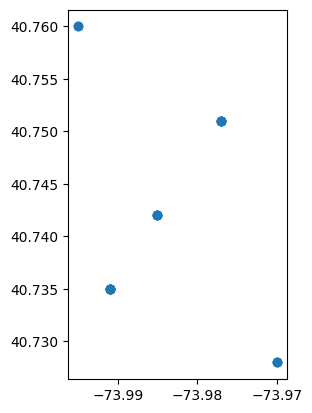

In [50]:
start_points.plot()

<Axes: >

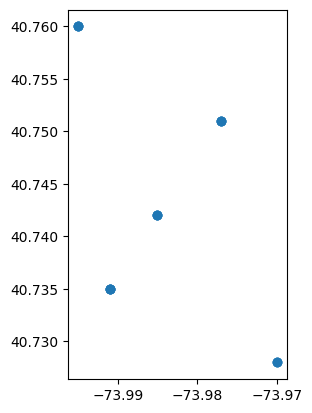

In [53]:
end_points = gpd.GeoDataFrame(
    trip_demo.copy(),
    geometry=gpd.points_from_xy(
        trip_demo["end_lng"],
        trip_demo["end_lat"]
    ),
    crs="EPSG:4326"
)

end_points.plot()

In [54]:
projected_crs = "EPSG:32618"

start_points_projected = start_points.to_crs(projected_crs)
end_points_projected = end_points.to_crs(projected_crs)

In [58]:
trip_demo["distance_m"] = start_points_projected.geometry.distance(
    end_points_projected.geometry
)

trip_demo["distance_km"] = trip_demo["distance_m"] / 1000


trip_demo.head()

,ride_id,start_station,started_at,start_lat,start_lng,end_station,ended_at,end_lat,end_lng,member_casual,duration_min,date,hour,day_name,month_name,distance_m,distance_km
0,1,Station A,2025-01-01 08:00:00,40.735,-73.991,Station B,2025-01-01 08:10:00,40.751,-73.977,member,10.0,2025-01-01,8,Wednesday,January,2133.621698,2.133622
1,2,Station A,2025-01-01 08:15:00,40.735,-73.991,Station B,2025-01-01 08:28:00,40.751,-73.977,member,13.0,2025-01-01,8,Wednesday,January,2133.621698,2.133622
2,3,Station A,2025-01-01 08:30:00,40.735,-73.991,Station B,2025-01-01 08:42:00,40.751,-73.977,casual,12.0,2025-01-01,8,Wednesday,January,2133.621698,2.133622
3,4,Station A,2025-01-01 09:00:00,40.735,-73.991,Station C,2025-01-01 09:18:00,40.742,-73.985,member,18.0,2025-01-01,9,Wednesday,January,927.671157,0.927671
4,5,Station A,2025-01-01 09:20:00,40.735,-73.991,Station C,2025-01-01 09:35:00,40.742,-73.985,casual,15.0,2025-01-01,9,Wednesday,January,927.671157,0.927671


In [59]:
df  = gpd.read_file("../data/citibike/JC/jersey-city-neighborhoods.geojson")

<Axes: >

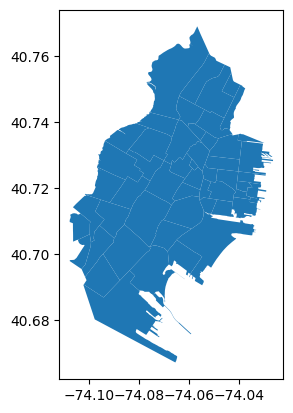

In [60]:
df.plot()

## Jersey

In [63]:
# eval: true
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile

### Downloading the Citi Bike Data for `202510`

In [ ]:
CITIBIKE_INDEX_URL = "https://s3.amazonaws.com/tripdata"
OUTPUT_DIR = "../data/test" # ձեզ մոտ թողեց citibike
PERIOD = "202510"

In [62]:
file_name = f"JC-{PERIOD}-citibike-tripdata.zip"
url = f"{CITIBIKE_INDEX_URL}/{file_name}"
url

'https://s3.amazonaws.com/tripdata/JC-202510-citibike-tripdata.zip'

In [ ]:
output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(exist_ok=True)
zip_path = output_dir / file_name

In [ ]:
print(f"Downloading: {url}")
urlretrieve(url, zip_path)

print(f"Saved ZIP file to: {zip_path}")


with ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(output_dir)

print(f"Extracted files into: {output_dir}")



Downloading: https://s3.amazonaws.com/tripdata/JC-202510-citibike-tripdata.zip
Saved ZIP file to: ../data/test/JC-202510-citibike-tripdata.zip
Extracted files into: ../data/test


### Removing the extracted ZIP file

In [66]:
zip_path.unlink()
print("ZIP file removed.")

ZIP file removed.


In [ ]:
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile

CITIBIKE_INDEX_URL = "https://s3.amazonaws.com/tripdata"
OUTPUT_DIR = "../data/test" # ձեզ մոտ թողեց citibike


### Function to generate periods in the format YYYYMM

In [9]:
def period_iterator(year:list,start_m:int, stop_m:int)->list:
    """
    year list of strings
    """
    YEAR = year
    MONTH =  [str(i+1) if i+1>9 else "0" + str(i+1) for i in range(start_m, stop_m)]

    periods = []

    for i in YEAR:
        for j in MONTH:
            k = i+j
            periods.append(k)
    # print(periods)
    return periods


In [10]:
PERIODS = period_iterator(["2025"],0,12)
PERIODS

['202501',
 '202502',
 '202503',
 '202504',
 '202505',
 '202506',
 '202507',
 '202508',
 '202509',
 '202510',
 '202511',
 '202512']

### Downlaoding for the Year 2025 and months from 1 to 12

In [ ]:
from pathlib import Path
from zipfile import ZipFile
from urllib.request import urlretrieve
from urllib.error import HTTPError, URLError

output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

for i in PERIODS:

    try:
        file_name = f"JC-{i}-citibike-tripdata.csv.zip"
        url = f"{CITIBIKE_INDEX_URL}/{file_name}"

        zip_path = output_dir / file_name
        urlretrieve(url, zip_path)

    except (HTTPError, URLError, FileNotFoundError):
        file_name = f"JC-{i}-citibike-tripdata.zip"
        url = f"{CITIBIKE_INDEX_URL}/{file_name}"

        zip_path = output_dir / file_name
        urlretrieve(url, zip_path)

    with ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(output_dir)
    print(f'{file_name}  Extracted')
    zip_path.unlink()
    print(f"{file_name} removed.")

# Oncee finishd

JC-202501-citibike-tripdata.csv.zip  Extracted
JC-202501-citibike-tripdata.csv.zip removed.
JC-202502-citibike-tripdata.csv.zip  Extracted
JC-202502-citibike-tripdata.csv.zip removed.
JC-202503-citibike-tripdata.csv.zip  Extracted
JC-202503-citibike-tripdata.csv.zip removed.
JC-202504-citibike-tripdata.csv.zip  Extracted
JC-202504-citibike-tripdata.csv.zip removed.
JC-202505-citibike-tripdata.csv.zip  Extracted
JC-202505-citibike-tripdata.csv.zip removed.
JC-202506-citibike-tripdata.csv.zip  Extracted
JC-202506-citibike-tripdata.csv.zip removed.
JC-202507-citibike-tripdata.csv.zip  Extracted
JC-202507-citibike-tripdata.csv.zip removed.
JC-202508-citibike-tripdata.csv.zip  Extracted
JC-202508-citibike-tripdata.csv.zip removed.
JC-202509-citibike-tripdata.csv.zip  Extracted
JC-202509-citibike-tripdata.csv.zip removed.
JC-202510-citibike-tripdata.zip  Extracted
JC-202510-citibike-tripdata.zip removed.
JC-202511-citibike-tripdata.csv.zip  Extracted
JC-202511-citibike-tripdata.csv.zip remov

### Removing `__MACOSX` files

In [ ]:
import shutil


shutil.rmtree(output_dir)